# Dynamical Systems Reconstruction with PLRNNs

This notebook demonstrates the full **Paradigm B** workflow in NeuralRNN: learning a generative RNN whose autonomous trajectories reproduce an observed dynamical system. We reconstruct a low-dimensional chaotic attractor with an autonomous shallow piece-wise linear RNN (`shallowPLRNN`) and its variants `DendPLRNN` and `ALRNN`. We use analytic fixed points and standard DSR metrics (`D_stsp`, `D_H`, `λ_max`).

> Reference: Durstewitz, D., Koppe, G. & Thurm, M.I. Reconstructing computational system dynamics from neural data with recurrent neural networks. Nat. Rev. Neurosci. 24, 693–710 (2023). https://doi.org/10.1038/s41583-023-00740-7.

In [74]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

sys.path.append('../src')
from neuralrnn import (
    AutoConfig, AutoModel, Trainer, TrainingArguments, load_dataset,
    SupervisedObjective, TeacherForcingObjective,
)
from neuralrnn.data import ReconstructionDataset, StandardScaler
from neuralrnn.analysis import (
    fit_pca, find_fixed_points, linearize, dominant_direction,
    compute_vector_field, state_space_divergence, power_spectrum_error,
    max_lyapunov_exponent, compute_manifold,
)

torch.manual_seed(0)
np.random.seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = 'cpu'
print('Using device:', device)

SAVE_DIR = Path('./models/05')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Generated figures live next to this notebook
FIG_DIR = Path('./figs/05')
FIG_DIR.mkdir(parents=True, exist_ok=True)

Using device: cpu


We start with the classic Lorenz-63 system. The goal is to train a shallowPLRNN so that its free-run trajectories visit the same butterfly-shaped attractor as the true system.

Observation dim N = 3 | train length T = 100000
activity (128, 100, 3)


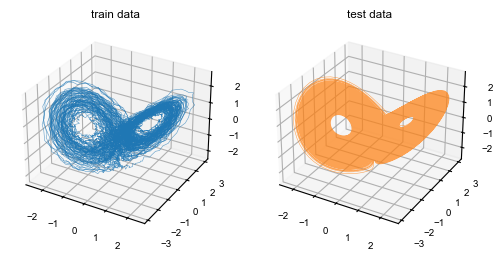

In [75]:
# Load the Lorenz-63 dataset (unified ReconstructionDataset, windowed timeseries mode).
ds_lorenz = load_dataset('lorenz63', sequence_length=100, batch_size=128, normalize=True)
print('Observation dim N =', ds_lorenz.N, '| train length T =', ds_lorenz.T)

batch = ds_lorenz.sample_batch()
fig = plt.figure(figsize=(6, 3))
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_title('train data')
for k, v in batch.items():
    if v is not None:
        print(k, tuple(v.shape))
        for i in range(v.shape[0]):
            ax1.plot3D(v[i, :, 0], v[i, :, 1], v[i, :, 2], lw=0.4, alpha=0.7, color='C0')
ax2 = fig.add_subplot(122, projection='3d')
v = ds_lorenz.test
ax2.plot3D(v[:, 0], v[:, 1], v[:, 2], lw=0.4, alpha=0.7, color='C1')
ax2.set_title('test data')
plt.savefig(FIG_DIR / "lorenz63_data.png", dpi=150)
plt.show()

### TLDR

For an autonomous system we set `input_dim=0`:

$$
z_t = A z_{t-1} + W_1 \mathrm{ReLU}(W_2 z_{t-1} + h_2) + h_1,
\qquad A=\mathrm{diag}.
$$

We use identity readout, so `latent_dim = output_dim = observation_dim = 3`. Generalized Teacher Forcing with a small `alpha` (0.125) stabilizes training on chaotic data.

### 1.1 The dynamical systems reconstruction (DSR) problem

We observe a time series $\{\mathbf{x}_t\}$, $\mathbf{x}_t \in \mathbb{R}^N$, sampled at interval $\Delta t$ from an underlying dynamical system (here the Lorenz-63 system, $\sigma=10$, $\rho=28$, $\beta=8/3$, sampled at $\Delta t = 0.01$ and standardized to zero mean / unit variance per channel). The goal of DSR is **not** good one-step-ahead prediction but a generative model whose **long-term autonomous behavior** — attractor geometry, temporal structure, stability properties — agrees with the observed system.

The PLRNN family formalizes this as a state-space model:

$$
\mathbf{z}_t = F_\theta(\mathbf{z}_{t-1}, \mathbf{s}_t) + \boldsymbol{\varepsilon}_t,
\qquad \boldsymbol{\varepsilon}_t \sim \mathcal{N}(\mathbf{0}, \boldsymbol{\Sigma})
$$
$$
\mathbf{x}_t = G_\varphi(\mathbf{z}_t) + \boldsymbol{\eta}_t,
\qquad \boldsymbol{\eta}_t \sim \mathcal{N}(\mathbf{0}, \boldsymbol{\Gamma})
$$

with latent states $\mathbf{z}_t \in \mathbb{R}^M$, optional external inputs $\mathbf{s}_t \in \mathbb{R}^K$ (dropped for autonomous systems, $K=0$), and an observation model $G_\varphi$ (identity on the first $N$ latent units throughout this notebook).

**Why piecewise-linear maps are special.** Because $F_\theta$ is built from ReLU nonlinearities, the latent state space is partitioned into **linear subregions** $\Omega$ by the on/off pattern of the ReLU units. Within each subregion the map is affine,

$$
\mathbf{z}_t = \bigl(\mathbf{A} + \mathbf{W}\mathbf{D}_{\Omega}\bigr)\,\mathbf{z}_{t-1} + \mathbf{h}_{\mathrm{eff}},
$$

where $\mathbf{D}_{\Omega} = \mathrm{diag}(d_1, \dots)$ is a binary diagonal matrix indicating which ReLU units are active. With $L$ ReLU nonlinearity arguments there are at most $2^L$ subregions. This buys three things that generic RNNs do not have: (i) **analytic Jacobians** $\mathbf{J}_t$, hence Lyapunov exponents without autodiff; (ii) **closed-form fixed points / cycles** via SCYFI (§1.5); (iii) **linear-subregion analyses** of the learned dynamics (§1.7).

### 1.2 The shallow PLRNN (shPLRNN)

State equation:

$$
\mathbf{z}_t = \mathbf{A}\mathbf{z}_{t-1} + \mathbf{W}_1\,\mathrm{ReLU}(\mathbf{W}_2\mathbf{z}_{t-1} + \mathbf{h}_2) + \mathbf{h}_1 + \mathbf{C}\mathbf{s}_t
$$

| symbol | shape | meaning |
|---|---|---|
| $\mathbf{z}_t$ | $\mathbb{R}^M$ | latent state (`latent_dim`); observations = first $N$ units (identity readout) |
| $\mathbf{A}$ | $M \times M$, diagonal | self-recurrence (leak); init $\sim U(0.5, 0.9)$ |
| $\mathbf{W}_1$ | $M \times L$ | hidden $\to$ latent read-down; init $\sim U(\pm 1/\sqrt{L})$ |
| $\mathbf{W}_2$ | $L \times M$ | latent $\to$ hidden read-up; init $\sim U(\pm 1/\sqrt{M})$ |
| $\mathbf{h}_1, \mathbf{h}_2$ | $\mathbb{R}^M, \mathbb{R}^L$ | biases ($\mathbf{h}_1 = 0$ at init) |
| $\mathbf{C}$ | $M \times K$ | input weights (only for non-autonomous models, see Part II) |
| $L$ | — | `hidden_dim`, the size of the ReLU hidden layer |

**Jacobian** (needed for Lyapunov exponents and stability):

$$
\mathbf{J}_t = \mathbf{A} + \mathbf{W}_1 \mathbf{D}_{\Omega(t)} \mathbf{W}_2,
\qquad \mathbf{D}_{\Omega(t)} = \mathrm{diag}\bigl(\mathbb{1}[\mathbf{W}_2\mathbf{z}_t + \mathbf{h}_2 > \mathbf{0}]\bigr)
$$

**Why can the shallow PLRNN use $M = N = 3$ for Lorenz, and why does it need `hidden_dim`?** The recurrence is bottlenecked through the $L$-dimensional ReLU layer: the nonlinearity — and hence the number of linear subregions, at most $\sum_{k=0}^{M}\binom{L}{k}$ — is supplied by the hidden layer, not by the latent width. The latent dimension only has to cover the **embedding dimension of the observed system** (3 for Lorenz-63), while `hidden_dim` $L$ is the expressivity knob. A vanilla PLRNN of the same $M$ would offer only $2^M$ subregions.

### 1.3 Training: generalized teacher forcing (GTF)

**The problem.** BPTT through a chaotic map contains Jacobian products

$$
\frac{\partial \mathbf{z}_t}{\partial \mathbf{z}_r} = \prod_{k=0}^{t-r-1} \mathbf{J}_{t-k},
$$

whose norm grows $\sim e^{\lambda_{\max}(t-r)}$: for a chaotic target ($\lambda_{\max} > 0$) gradients explode long before the loss can shape the attractor.

**The fix.** Interleave the model's own state with the teacher (data) state $\bar{\mathbf{z}}_t$ at every step,

$$
\tilde{\mathbf{z}}_t = (1 - \alpha)\,\mathbf{z}_t + \alpha\,\bar{\mathbf{z}}_t,
\qquad \alpha \in (0, 1],
$$

so the gradient is damped geometrically, $\frac{\partial \mathbf{z}_t}{\partial \mathbf{z}_r} = (1-\alpha)^{t-r}\prod \tilde{\mathbf{J}}_{t-k}$. The theoretically motivated choice is $\alpha^* = 1 - 1/\tilde{\sigma}_{\max}$ with $\tilde{\sigma}_{\max}$ the largest Jacobian singular value; in practice $\alpha$ is a small constant with a **large impact on reconstruction quality**.

The loss is plain MSE on one-step-ahead predictions. Variants used below: **sparse** forcing (full replacement $\alpha = 1$ of the observed units only every $\tau$ steps — the ALRNN/dendPLRNN references) and **noise on the teacher signal** (`tf_noise`). All of these map onto `TeacherForcingObjective(alpha, forcing_interval, tf_noise)`.

### Build and train the autonomous shallowPLRNN

In [76]:
lorenz_ckpt = SAVE_DIR / 'ckpt_lorenz_plrnn'
overwrite = False
if (lorenz_ckpt / 'config.json').exists() and not overwrite:
    print('Loading pre-trained Lorenz-63 PLRNN...')
    model_lorenz = AutoModel.from_pretrained(lorenz_ckpt)
else:
    cfg_lorenz = AutoConfig.for_model(
        'shallow_plrnn',
        input_dim=0,
        latent_dim=ds_lorenz.N,
        output_dim=ds_lorenz.N,
        hidden_dim=50,
        autonomous=True,
    )
    model_lorenz = AutoModel.from_config(cfg_lorenz)
    print(model_lorenz.__class__.__name__, '| #params =', model_lorenz.num_parameters())

    objective = TeacherForcingObjective(alpha=0.125)
    args = TrainingArguments(
        max_steps=4000,
        learning_rate=1e-3,
        grad_clip_norm=1.0,
        log_every=500,
    )
    Trainer(model_lorenz, ds_lorenz, objective, args).train()
    model_lorenz.save_pretrained(lorenz_ckpt)
    print('Saved to', lorenz_ckpt)

Loading pre-trained Lorenz-63 PLRNN...


### 1.4 Evaluation metrics

**$D_{\mathrm{stsp}}$ — state-space divergence** (geometric agreement of the invariant measures). Bin the state space into $K$ hypercubes ($n_{\text{bins}} = 30$ per dimension, range taken from the true data) and compare the probability mass distributions of true and generated orbits by Kullback–Leibler divergence with Laplace smoothing ($\alpha = 10^{-5}$):

$$
D_{\mathrm{stsp}} = \sum_{k=1}^{K} \hat{p}_{\mathrm{true}}^{(k)}(\mathbf{x}) \log \frac{\hat{p}_{\mathrm{true}}^{(k)}(\mathbf{x})}{\hat{p}_{\mathrm{gen}}^{(k)}(\mathbf{x})}
$$

For $N \gtrsim 6$ dimensions binning becomes infeasible, so a **GMM Monte-Carlo variant** is used: one isotropic Gaussian per data point (covariance $= \mathbf{I}\cdot$ scaling), and the KL is estimated by sampling 1000 points from the "true" GMM (Hershey & Olsen 2007). `state_space_divergence(..., method='auto')` switches at $\dim \le 4$.

**$D_H$ — power-spectrum (Hellinger) distance** (temporal agreement). Per dimension: standardize $\tilde{x} = (x - \bar{x})/\sigma_x$, compute the power spectrum $\lvert\mathrm{rfft}(\tilde{x})\rvert^2 \cdot 2/T$, smooth with a Gaussian kernel ($\texttt{smoothing} = 20$), normalize to unit sum, and take the Hellinger distance between the true and generated spectra, averaged over dimensions:

$$
H(F, G) = \sqrt{1 - \sum_{\omega}\sqrt{F(\omega)\,G(\omega)}} \in [0, 1]
$$

**$\lambda_{\max}$ — largest Lyapunov exponent** (dynamical agreement). For the discrete-time map, estimated with the Benettin/QR algorithm: discard a transient, iterate while repeatedly multiplying an orthonormal frame $Q$ by the analytic Jacobians, re-orthonormalize every `ons` steps and accumulate $\log|R_{00}|$:

$$
\lambda_{\max} = \lim_{T \to \infty} \frac{1}{T} \log \Bigl\lVert \prod_{r=0}^{T-2} \mathbf{J}_{T-r} \Bigr\rVert_2
$$

Divide by the sampling interval $\Delta t = 0.01$ to compare with the continuous-time Lorenz-63 ground truth $\lambda_{\max} \approx 0.906$.

All three are implemented in `neuralrnn.analysis` (`state_space_divergence`, `power_spectrum_error`, `max_lyapunov_exponent`).

We roll the trained model out without teacher forcing and compare the generated trajectory to the true test trajectory. `D_stsp` measures state-space distributional mismatch, `D_H` compares power spectra, and `λ_max` estimates the largest Lyapunov exponent.

**Important:** The shallowPLRNN is a discrete-time map trained on Lorenz-63 data sampled at `Δt = 0.01`. The raw QR-based exponent is therefore a *discrete-time* value. To compare with the continuous-time Lorenz-63 ground truth (`λ_max ≈ 0.906`), we divide the discrete-time estimate by `dt = 0.01`. 

In [77]:
true = ds_lorenz.test.numpy() if ds_lorenz.test is not None else ds_lorenz.X.numpy()
z0 = torch.zeros(1, ds_lorenz.N)
gen = model_lorenz.generate(z0, n_steps=true.shape[0] - 1)[0].numpy()  # (T, N)

D_stsp = state_space_divergence(gen, true)
D_H = power_spectrum_error(true, gen, smoothing=20.0)
# The PLRNN is a discrete-time map trained on data sampled at dt=0.01.
# To compare with the continuous-time Lorenz-63 value (~0.906), divide by dt.
lam = max_lyapunov_exponent(
    model_lorenz,
    torch.tensor(gen[-1], dtype=torch.float32),
    T=10000,
    T_trans=1000,
    ons=10,
    dt=getattr(ds_lorenz, 'dt', 0.01),
)

print(f'D_stsp     = {D_stsp:.4f}')
print(f'D_H        = {D_H:.4f}')
print(f'lambda_max = {lam:.3f}')

D_stsp     = 1.3247
D_H        = 0.1060
lambda_max = 0.965


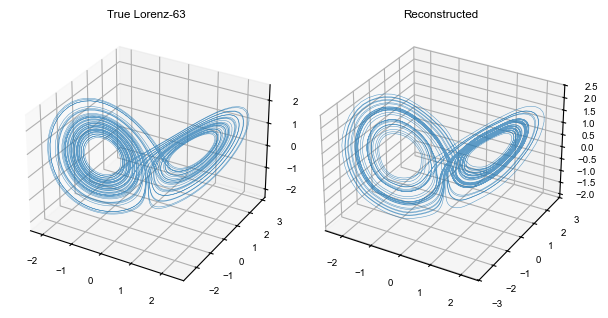

In [78]:
fig = plt.figure(figsize=(6, 3))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(*true[:5000].T, lw=0.4, alpha=0.7)
ax1.set_title('True Lorenz-63')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(*gen[:5000].T, lw=0.4, alpha=0.7)
ax2.set_title('Reconstructed')

plt.tight_layout()
plt.savefig(FIG_DIR / "lorenz63_reconstruction.png", dpi=150)
plt.show()

### 1.5 Analytic fixed points and cycles: SCYFI

Within one linear subregion $\Omega$ the shPLRNN is affine, so its fixed-point equation has a **closed-form solution**:

$$
\mathbf{z}^* = \Bigl(\mathbb{1} - \bigl(\mathbf{A} + \mathbf{W}_1 \mathbf{D}_{\Omega} \mathbf{W}_2\bigr)\Bigr)^{-1} \bigl(\mathbf{W}_1 \mathbf{D}_{\Omega} \mathbf{h}_2 + \mathbf{h}_1\bigr)
$$

If $\mathbf{z}^*$ lies inside the same subregion $\Omega$ it was computed for, it is a **real** fixed point, otherwise a **virtual** one. Enumerating all $\sim 2^L$ subregions is infeasible; **SCYFI** (Searcher for Cycles and Fixed points) instead (i) samples a random ReLU configuration, (ii) solves for the candidate, and (iii) re-initializes the search **in the subregion of the last visited virtual FP**, which empirically converges to the real FPs in a handful of iterations. `outer_it` random restarts and `inner_it` virtual-FP-following steps per restart; the counters reset whenever a new FP is found. The same construction with iterated maps yields order-$k$ cycles (`max_order`), and stability follows from the eigenvalues of the per-region Jacobian product (discrete-time map: $|\lambda| > 1$ = unstable).

**Ground truth for Lorenz-63** (standardized coordinates): exactly 3 fixed points — the origin and $\mathrm{FP}_{\pm} = \bigl(\pm\sqrt{\beta(\rho-1)}, \rho - 1\bigr)$.

Found 3 fixed points
  z* = [-0.018  0.024 -2.77 ] | stable: False | max|eig| = 1.134
  z* = [1.123 0.973 0.475] | stable: False | max|eig| = 1.017
  z* = [-1.095 -0.979  0.327] | stable: True | max|eig| = 0.948


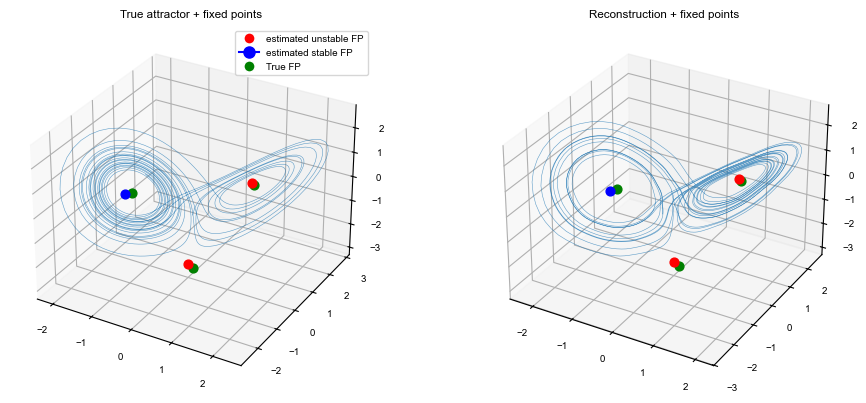

In [79]:
fps_lorenz = find_fixed_points(
    model_lorenz,
    backend='analytic',
    max_order=1,
    outer_it=30,
    inner_it=10,
)
print(f'Found {len(fps_lorenz)} fixed points')
for p in fps_lorenz:
    print('  z* =', np.round(p.z, 3),
          '| stable:', p.is_stable,
          '| max|eig| =', round(float(np.max(np.abs(p.eigenvalues))), 3))

true_FPs = np.array([[-0.97025859,  1.16357464,  0.09665803], 
                      [-0.86533984,  1.03770608,  0.08618312],
                      [ 0.37320716,  0.37320716, -2.92500668]]).T


fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(*true[:2000].T, lw=0.4, alpha=0.7)
for p in fps_lorenz:
    ax1.scatter(*p.z, c='red' if not p.is_stable else 'blue', s=40)
for p in true_FPs:
    ax1.scatter(*p, c='green', s=40)
ax1.set_title('True attractor + fixed points')
ax1.legend(handles=[
    Line2D([0], [0], marker='o', color='w', label='estimated unstable FP', markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='b', label='estimated stable FP', markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='True FP', markerfacecolor='green', markersize=8),
])

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(*gen[:2000].T, lw=0.4, alpha=0.7)
for p in fps_lorenz:
    ax2.scatter(*p.z, c='red' if not p.is_stable else 'blue', s=40)
for p in true_FPs:
    ax2.scatter(*p, c='green', s=40)
ax2.set_title('Reconstruction + fixed points')

plt.tight_layout()
plt.savefig(FIG_DIR / "lorenz63_fixed_points.png", dpi=150)
plt.show()

#### How many fixed points *should* a good reconstruction have?

Lorenz-63 has exactly 3 fixed points (origin + $\mathrm{FP}_{\pm}$), and a converged shPLRNN should reproduce exactly these. With the **current** checkpoint (`ckpt_lorenz_plrnn`), seeded SCYFI runs find exactly 3 FPs in 30/30 trials. The **previous** checkpoint (`ckpt_lorenz_plrnn_old`, kept for reference) consistently yields **4** — the extra one sits at $z \approx (0.50, -0.90, 5.36)$, more than 5 standard-deviation units away from any true FP and **far outside the attractor**.

An extra FP like this is not a SCYFI malfunction and not a contradiction of theory: teacher forcing only constrains $F_\theta$ **on and near the data manifold**; in regions of state space the data never visit, the piecewise-linear map is free to develop additional (usually unstable or weakly attracting) fixed points. Even the *reference* pretrained ALRNN (`lorenz_m20_p2`, Brenner et al. 2024) owns such an off-attractor FP at $z_3 \approx 4.7$. Practical implications: (i) judge FP recovery by location, not only by count — off-attractor FPs are harmless for reconstruction quality because trajectories never go there, but they flag unconstrained extrapolation; (ii) better-converged models (like the current checkpoint) tend to shed them; (iii) SCYFI itself is stochastic (random initial subregions), so with a small search budget the found set can vary between runs — seed `np.random` for reproducibility, as done below.

### 1.6 PLRNN-family variants on Lorenz-63 (reference settings)

We now train the two PLRNN variants with the configurations of their reference
implementations — the key difference from the shallow model being a **latent
dimension M larger than the observation dimension N = 3** (the observations are
the first N latent units, read out identically):

* **ALRNN** ([Brenner et al. 2024](https://arxiv.org/abs/2402.12236)):
  M = 20 units, only the last P = 2 are ReLU (`n_linear = 18`), paper
  initialization (A = diag of a normalized positive-definite matrix,
  W ~ N(0, 0.01²)), learned observation→latent lift B (`learn_z0`), and
  **sparse hard teacher forcing**: full replacement (α = 1) of the observed
  units only every τ = 16 steps.
* **dendPLRNN (clipped-PLRNN)** ([Brenner et al. 2022](https://arxiv.org/abs/2205.13989)):
  M = 22 units, B = 20 spline bases per unit with the **clipped basis
  expansion** α_b(ReLU(z − H_b) − ReLU(z)) that guarantees bounded orbits,
  Talathi–Vartak initialization, thresholds covering the data range, hard
  forcing every τ = 25 steps with 5 % Gaussian noise on the teacher signal.

Both use RAdam with an exponential lr decay (1e-3 → 1e-5 over the full 100k
steps of the papers) and select the best checkpoint by the free-run D_stsp
during training. `SCALE = 'debug'` runs a shortened 20k-step schedule (lr
decayed only to ~4e-4, matching the reference lr trajectory at step 20k);
`SCALE = 'full'` reproduces the paper schedule.

#### dendPLRNN: equations and parameters

Each latent unit carries its own **spline basis expansion** with $B$ bases (`n_bases`):

$$
\boldsymbol{\phi}(\mathbf{z}_{t-1}) = \sum_{b=1}^{B} \alpha_b\,\mathrm{ReLU}(\mathbf{z}_{t-1} - \mathbf{H}_b),
\qquad
\mathbf{z}_t = \mathbf{A}\mathbf{z}_{t-1} + \mathbf{W}\,\boldsymbol{\phi}(\mathbf{z}_{t-1}) + \mathbf{h} + \mathbf{C}\mathbf{s}_t
$$

with learnable slopes $\alpha_b$ and thresholds $\mathbf{H}_b$. With **clipping** (`use_clipping=True`, recommended) each basis is replaced by the mirrored, bounded version $\alpha_b\bigl(\mathrm{ReLU}(\mathbf{z} - \mathbf{H}_b) - \mathrm{ReLU}(\mathbf{z})\bigr)$.

* **Theorem 1** (Brenner et al. 2022): an $M$-dim dendPLRNN with $B$ bases is mathematically equivalent to an $(M \times B)$-dim conventional PLRNN — this is exactly how `analytic_parameters()` exposes the model to SCYFI ($\mathbf{W}_2$ = stacked identities, $\mathbf{h}_2 = -\mathbf{H}$, $\mathbf{W}_1 = [\alpha_b\,\mathbf{W}]$).
* **Theorem 2**: clipped bases $\{-\alpha_b, 0\}$ together with $\sigma_{\max}(\mathbf{A}) < 1$ guarantee **bounded orbits** — the principled fix against free-run divergence.
* *Thresholds* $\mathbf{H}_b$ are initialized uniformly over the data range (`threshold_range`); the recurrence is initialized with the Talathi–Vartak split $\mathbf{A}\mathbf{W} = (\mathbb{1} + \mathbf{R}^\top\mathbf{R}/M)/\lambda_{\max}$ (`init_scheme='paper'`), which starts the model contractive.
* *Training*: BPTT with **sparse teacher forcing** — the first $N$ latent units are hard-reset to the observations every $\tau = 25$ steps, with 5 % Gaussian noise on the teacher signal (`tf_noise=0.05`). `learn_z0` adds a lift $\mathbf{z}_0 = \mathbf{x}_0\mathbf{B}$ (first $N$ dims then overwritten by $\mathbf{x}_0$) so free runs start from a data point.

#### ALRNN: equations and parameters

Only the last $P \ll M$ units are nonlinear (`n_linear` $= M - P$ linear units):

$$
\boldsymbol{\Phi}^*(\mathbf{z}) = \bigl[z_1, \dots, z_{M-P}, \mathrm{ReLU}(z_{M-P+1}), \dots, \mathrm{ReLU}(z_M)\bigr]^\top,
\qquad
\mathbf{z}_t = \mathbf{A}\mathbf{z}_{t-1} + \mathbf{W}\boldsymbol{\Phi}^*(\mathbf{z}_{t-1}) + \mathbf{h}
$$

so the state space splits into only $2^P$ linear subregions. This buys a rigorous **symbolic-dynamics** description: an orbit is eventually-constant / $p$-periodic / aperiodic in its subregion-visitation sequence iff the underlying dynamics settles onto a fixed point / $p$-cycle / chaotic set — and the number of *used* subregions characterizes the system (Lorenz-63 → 3, see §1.7).

* *Why $M = 20$ when $P = 2$?* The $M - P$ **linear units act as a dynamical basis / memory** that embeds and unfolds the flow while only $P$ units bend it; the reference uses $M = 20$, $P = 2$ (a larger pretrained variant uses $M = 30$, $P = 10$). Rule of thumb: keep $P$ small (2–10) and choose $M$ an order of magnitude larger than $N$.
* *Init* (`init_scheme='paper'`): $\mathbf{A}$ = diagonal of a normalized positive-definite matrix $\bigl((\mathbf{R}^\top\mathbf{R}/M + \mathbb{1})/\lambda_{\max}\bigr)$ (eigenvalues $\le 1$), $\mathbf{W} \sim \mathcal{N}(0, 0.01^2)$, $\mathbf{h} = 0$ — again contractive at start. `learn_z0` as for dendPLRNN.
* *Training*: **identity teacher forcing** of the first $N$ units every $\tau = 16$ steps (`alpha=1.0, forcing_interval=16`).

#### Why does the shallow PLRNN need `hidden_dim`, but the variants do not?

The shPLRNN's recurrence is **bottlenecked through an explicit hidden layer**: $\mathbf{W}_2$ reads the state up into $L$ ReLU units and $\mathbf{W}_1$ reads them back down, so the hidden layer supplies the nonlinearity ($\le \sum_{k \le M}\binom{L}{k}$ subregions) and $M$ can stay at the embedding dimension $N = 3$. ALRNN and dendPLRNN instead apply a **full $M \times M$ matrix $\mathbf{W}$ to a nonlinear readout of the latent state itself** (ReLU on $P$ units, or spline bases on every unit) — there is no hidden layer to size. Their expressivity knobs are $(M, P)$ and $(M, B)$ respectively: dendPLRNN trades latent width for bases (effective PLRNN dimension $M \cdot B$ by Theorem 1), while the ALRNN deliberately minimizes nonlinearity ($2^P$ regions) and spends the extra linear latents on dynamical embedding.

#### Practical parameter guide (from the references)

| knob | model | rule of thumb |
|---|---|---|
| `latent_dim` $M$ | shPLRNN | $= N$ (embedding dim of the observed system) |
| `hidden_dim` $L$ | shPLRNN | 50–100; the expressivity knob, increase for complex attractors |
| `latent_dim` $M$ | ALRNN | $\approx 20$–$30$ ($\gg N$), linear units = dynamical basis |
| `n_linear` | ALRNN | $M - P$ with $P$ small (2–10); Lorenz: $P = 2$ |
| `latent_dim` $M$ | dendPLRNN | comparable to ALRNN (22 here); traded against $B$ |
| `n_bases` $B$ | dendPLRNN | 10–20; `threshold_range` must cover the data range |
| `use_clipping` | dendPLRNN | `True` for bounded free-run orbits (Theorem 2) |
| `init_scheme='paper'` | ALRNN/dend | contractive start; strongly recommended with sparse forcing |
| `learn_z0` | ALRNN/dend | learnable lift $\mathbf{z}_0 = \mathbf{x}_0\mathbf{B}$ for free-run starts |
| `alpha` / `forcing_interval` | all | GTF $\alpha \approx 0.1$ every step, **or** hard forcing $\alpha = 1$ every $\tau \approx 16$–$25$ steps; huge effect on quality |
| `tf_noise` | sparse forcing | ~5 % noise on the teacher signal improves robustness |

Always standardize the data first (`normalize=True`), decay the learning rate exponentially to $\sim 10^{-5}$, and select checkpoints by free-run $D_{\mathrm{stsp}}$.

In [80]:
SCALE = 'debug'   # 'debug' (20k steps) or 'full' (100k steps, paper setting)
MAX_STEPS = {'debug': 20000, 'full': 100000}[SCALE]
# Reference lr decays 1e-3 -> 1e-5 over 100k steps; at step 20k it is only ~4e-4.
LR_END = {'debug': 4e-4, 'full': 1e-5}[SCALE]

# normalized test attractor for free-run evaluation / model selection
true_norm = ds_lorenz.normalizer.transform(ds_lorenz.test).numpy()


def lorenz_eval_fn(model):
    """Free-run D_stsp / D_H against the normalized test series (for model selection)."""
    model = model.to(device)
    z0 = model.init_state_from_obs(torch.from_numpy(true_norm[:1]).float().to(device))
    gen = model.generate(z0, n_steps=11_000)[0, 1001:, :ds_lorenz.N].cpu().numpy()
    return {
        'd_stsp': state_space_divergence(gen, true_norm[:10_000]),
        'd_h': power_spectrum_error(true_norm[:10_000], gen),
    }


def train_lorenz_variant(model_type, config_kwargs, objective):
    """Train or load a PLRNN-family variant on the Lorenz-63 dataset."""
    ckpt = SAVE_DIR / f'ckpt_lorenz_{model_type}_{SCALE}'
    if (ckpt / 'config.json').exists():
        print(f'Loading existing {model_type} ({SCALE}) checkpoint...')
        return AutoModel.from_pretrained(ckpt).to(device)
    cfg = AutoConfig.for_model(
        model_type,
        input_dim=0,
        output_dim=ds_lorenz.N,      # observations = first N latent units
        autonomous=True,
        **config_kwargs,
    )
    model = AutoModel.from_config(cfg).to(device)
    print(model.__class__.__name__, '| #params =', model.num_parameters())
    args = TrainingArguments(
        max_steps=MAX_STEPS,
        learning_rate=1e-3,
        lr_scheduler='exponential',
        lr_end=LR_END,
        optimizer='radam',
        grad_clip_norm=10.0,
        log_every=1000,
        eval_every=1000,
        eval_metric='d_stsp',        # keep the checkpoint with the best free-run D_stsp
        keep_best=True,
        device=str(device),
    )
    Trainer(model, ds_lorenz, objective, args, eval_fn=lorenz_eval_fn).train()
    model.save_pretrained(ckpt)
    print('Saved', model_type, 'to', ckpt)
    return model


model_lorenz_dend = train_lorenz_variant(
    'dend_plrnn',
    {'latent_dim': 22, 'n_bases': 20, 'use_clipping': True,
     'threshold_range': (float(ds_lorenz.X.min()), float(ds_lorenz.X.max())),
     'init_scheme': 'paper', 'learn_z0': True},
    TeacherForcingObjective(alpha=1.0, forcing_interval=25, tf_noise=0.05),
)
model_lorenz_alrnn = train_lorenz_variant(
    'alrnn',
    {'latent_dim': 20, 'n_linear': 18, 'init_scheme': 'paper', 'learn_z0': True},
    TeacherForcingObjective(alpha=1.0, forcing_interval=16),
)

Loading existing dend_plrnn (debug) checkpoint...
Loading existing alrnn (debug) checkpoint...


#### Free-run evaluation and comparison

We roll out each variant from the first test point and report the same DSR metrics used for shallowPLRNN. Because all models use `latent_dim=3` and identity readout, the generated trajectories are directly comparable to the ground truth.

In [81]:
def eval_lorenz_variant(model, name):
    """Evaluate a trained variant on the Lorenz-63 test attractor (M >= N)."""
    model = model.to(device)
    z0 = model.init_state_from_obs(torch.from_numpy(true_norm[:1]).float().to(device))
    gen_lat = model.generate(z0, n_steps=true_norm.shape[0] - 1)[0].cpu().numpy()  # (T, M)
    gen = gen_lat[:, :ds_lorenz.N]                                                # observed dims
    d_stsp = state_space_divergence(gen, true_norm)
    d_h = power_spectrum_error(true_norm, gen, smoothing=20.0)
    lam = max_lyapunov_exponent(
        model,
        torch.tensor(gen_lat[-1], dtype=torch.float32, device=device),
        T=10000,
        T_trans=2000,
        ons=10,
        dt=getattr(ds_lorenz, 'dt', 0.01),
    )
    fps = find_fixed_points(
        model, backend='auto', max_order=1, outer_it=30, inner_it=10
    )
    d_h_str = f'{d_h:.4f}' if not np.isnan(d_h) else 'nan'
    print(f'{name:18s} D_stsp={d_stsp:.4f}  D_H={d_h_str}  '
          f'lambda_max/dt={lam:.3f}  #FP={len(fps)}')
    return gen, fps


gen_lorenz_dend, fps_lorenz_dend = eval_lorenz_variant(model_lorenz_dend, 'dendPLRNN')
gen_lorenz_alrnn, fps_lorenz_alrnn = eval_lorenz_variant(model_lorenz_alrnn, 'ALRNN')

dendPLRNN          D_stsp=1.2558  D_H=0.2081  lambda_max/dt=0.641  #FP=3
ALRNN              D_stsp=1.9609  D_H=0.2066  lambda_max/dt=0.930  #FP=4


#### Side-by-side trajectory plots

The 3-D free-run trajectories let us visually compare how well each variant captures the butterfly-shaped Lorenz attractor.

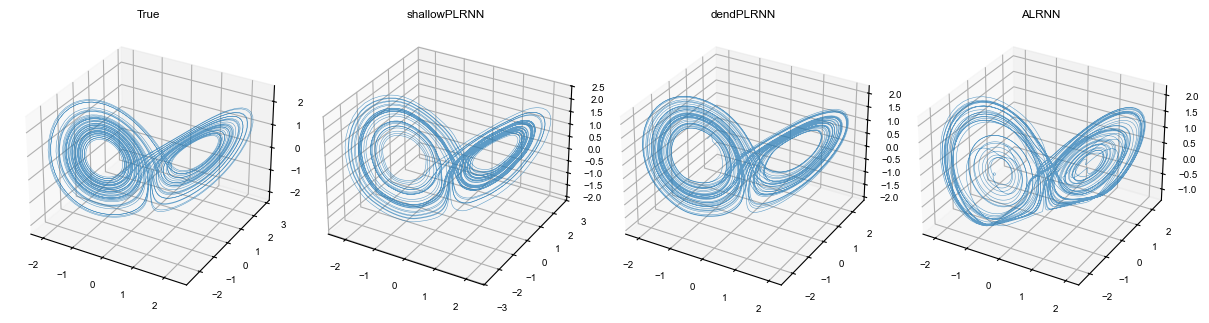

In [93]:
fig = plt.figure(figsize=(12, 3))
titles = ['True', 'shallowPLRNN', 'dendPLRNN', 'ALRNN']
trajs = [true[:5000], gen[:5000], gen_lorenz_dend[:5000], gen_lorenz_alrnn[:5000]]
for i, (traj, title) in enumerate(zip(trajs, titles)):
    ax = fig.add_subplot(1, 4, i + 1, projection='3d')
    ax.plot(*traj.T, lw=0.4, alpha=0.7)
    ax.set_title(title)
plt.tight_layout()
plt.savefig(FIG_DIR / "lorenz63_variants_trajectories.png", dpi=150)
plt.show()

#### Variant fixed points on the attractor — and why we used to find only one

Both variants expose `analytic_parameters()`, i.e. an **equivalent shallow-PLRNN form** of their map (dendPLRNN via Theorem 1 with effective hidden size $M(B{+}1)$, ALRNN via $\mathbf{A}_{\mathrm{eff}} = \mathrm{diag}(\mathbf{A}) + \mathbf{W}[:,{:}M{-}P]\mathbf{S}$, $\mathbf{W}_1 = \mathbf{W}[:,M{-}P{:}]$, $\mathbf{W}_2$ = selector of the last $P$ rows), so the **same SCYFI solver** applies and the answer is: yes, their fixed points can be overlaid on the trajectory plots exactly like the shPLRNN's. The FPs live in $\mathbb{R}^M$, but since the observations are the first $N = 3$ latent units, we simply scatter their first three coordinates.

The earlier `#FP=1` was **not** a property of the models but an artifact of the original CNS2023 deduplication (see §1.5): in a 20/22-dim latent space, genuinely distinct FPs often share one 2-decimal-rounded coordinate, so the element-wise `np.isin` dedup rejected every new FP after the first — each run returned exactly one, but *different* seeds returned *different* ones (3 distinct FPs across 5 seeds). With the fixed vector-wise dedup (`dedup_tol=1e-2`), a single run at the usual budget (`outer_it=30, inner_it=10`) now recovers **3 FPs for dendPLRNN** (matching the true ones) and **4 for the ALRNN** — the 4th sits at $z_3 \approx 2.5$, off the attractor, the same kind of spurious off-manifold FP discussed above (the reference pretrained ALRNN has one at $z_3 \approx 4.7$).

dendPLRNN: 3 fixed points
  z*[:3] = [-0.127 -0.023 -2.154] | stable: False | max|eig| = 1.14
  z*[:3] = [-1.028 -0.879  0.341] | stable: False | max|eig| = 1.013
  z*[:3] = [1.126 0.956 0.485] | stable: False | max|eig| = 1.011
ALRNN: 4 fixed points
  z*[:3] = [-0.952 -0.847  0.178] | stable: False | max|eig| = 1.003
  z*[:3] = [ 0.03  -0.014 -1.333] | stable: False | max|eig| = 1.088
  z*[:3] = [0.935 0.823 0.198] | stable: False | max|eig| = 1.003
  z*[:3] = [-5.200e-02  2.000e-03  2.457e+00] | stable: False | max|eig| = 1.101


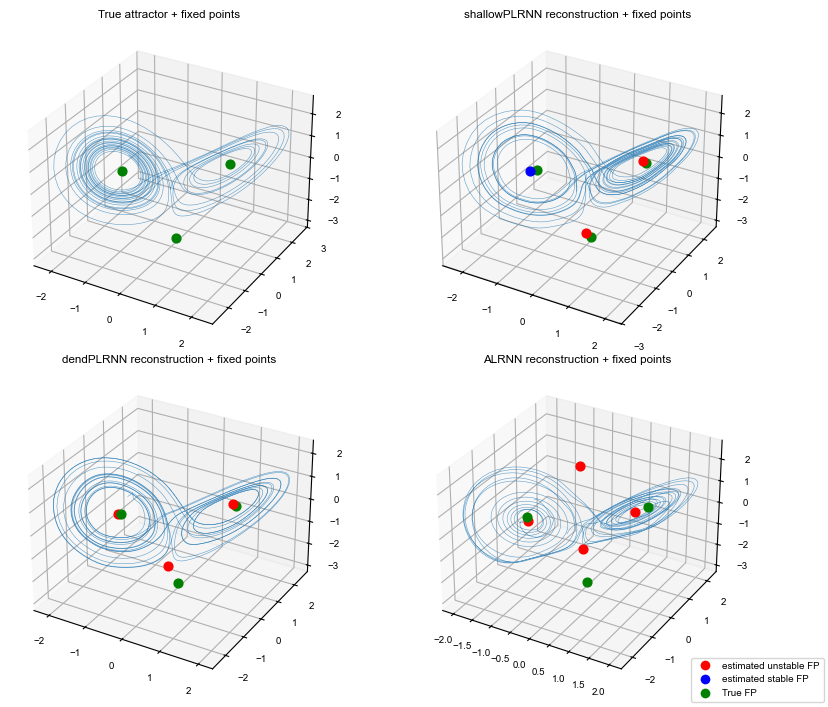

In [92]:
# Variant fixed points overlaid on the trajectories (observed = first 3 latent dims).
# SCYFI samples random initial ReLU configurations from global np.random -> seed it.
np.random.seed(0)
fps_lorenz_dend = find_fixed_points(model_lorenz_dend, backend='analytic',
                                    max_order=1, outer_it=30, inner_it=10)
fps_lorenz_alrnn = find_fixed_points(model_lorenz_alrnn, backend='analytic',
                                     max_order=1, outer_it=30, inner_it=10)
for name, fps in [('dendPLRNN', fps_lorenz_dend), ('ALRNN', fps_lorenz_alrnn)]:
    print(f'{name}: {len(fps)} fixed points')
    for p in fps:
        print('  z*[:3] =', np.round(p.z[:3], 3),
              '| stable:', p.is_stable,
              '| max|eig| =', round(float(np.max(np.abs(p.eigenvalues))), 3))

fig = plt.figure(figsize=(9, 7))
panels = [('True attractor', true_norm[:2000], None),
          ('shallowPLRNN reconstruction', gen[:2000], fps_lorenz),
          ('dendPLRNN reconstruction', gen_lorenz_dend[:2000], fps_lorenz_dend),
          ('ALRNN reconstruction', gen_lorenz_alrnn[:2000], fps_lorenz_alrnn)]
for i, (title, traj, fps) in enumerate(panels):
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    ax.plot(*traj.T, lw=0.4, alpha=0.7)
    if fps is not None:
        for p in fps:
            ax.scatter(*p.z[:3], c='red' if not p.is_stable else 'blue', s=40)
    for p in true_FPs:
        ax.scatter(*p, c='green', s=40)
    ax.set_title(f'{title} + fixed points')
fig.legend(handles=[
    Line2D([0], [0], marker='o', color='w', label='estimated unstable FP',
           markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='estimated stable FP',
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='True FP',
           markerfacecolor='green', markersize=8),
], loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR / "lorenz63_variants_fixed_points.png", dpi=150)
plt.show()

### 1.7 ALRNN linear-subregion analysis

The ALRNN's state space is partitioned into at most 2^P linear subregions by
the sign pattern of its P ReLU units; within each subregion the dynamics are
exactly linear. We analyze which subregions
the reconstructed attractor visits, how often, and how the trajectory
transitions between them — a symbolic-dynamics view of the reconstructed
system.

In [84]:
def region_analysis(bits):
    """Linear-subregion statistics from a (T, P) 0/1 activation-pattern array.

    Returns (codes, regions, frequencies, transition_matrix):
      codes:             (T,) region index per time step
      regions:           (R, P) unique bit patterns in order of first visit
      frequencies:       (R,) visit counts per region
      transition_matrix: (R, R) normalized transitions between pre-crossing
                         states, incl. self-connections (reference convention)
    """
    # unique regions in order of first visit
    seen, regions_list = {}, []
    for b in map(tuple, bits):
        if b not in seen:
            seen[b] = len(regions_list)
            regions_list.append(b)
    regions = np.array(regions_list)
    codes = np.array([seen[b] for b in map(tuple, bits)])
    frequencies = np.bincount(codes, minlength=len(regions))
    # transition matrix: states right BEFORE each boundary crossing; consecutive
    # pairs count as transitions, plus one self-connection per such state
    change_idx = np.where(np.any(bits[:-1] != bits[1:], axis=1))[0]
    crossing_codes = codes[change_idx]
    conn = np.zeros((len(regions), len(regions)))
    for i in range(len(crossing_codes) - 1):
        conn[crossing_codes[i], crossing_codes[i + 1]] += 1
    for c in crossing_codes:
        conn[c, c] += 1
    conn /= conn.sum()
    return codes, regions, frequencies, conn


# Free-run latent trajectory of the ALRNN (full M-dim states)
model_lorenz_alrnn = model_lorenz_alrnn.to(device)
z0_alrnn = model_lorenz_alrnn.init_state_from_obs(torch.from_numpy(true_norm[:1]).float().to(device))
lat_alrnn = model_lorenz_alrnn.generate(z0_alrnn, n_steps=11_000)[0, 1001:].cpu().numpy()  # (T, M)

P = model_lorenz_alrnn.n_relu                       # number of ReLU (PWL) units
bits = (lat_alrnn[:, -P:] > 0).astype(int)          # activation pattern of the P ReLU units
codes, regions, freqs, conn = region_analysis(bits)
print(f'{len(regions)} of 2^{P} = {2**P} linear subregions visited')
print('region bit patterns:', regions.tolist())
print('visit frequencies:', freqs)

4 of 2^2 = 4 linear subregions visited
region bit patterns: [[1, 1], [0, 1], [1, 0], [0, 0]]
visit frequencies: [3122 4152 2508  218]


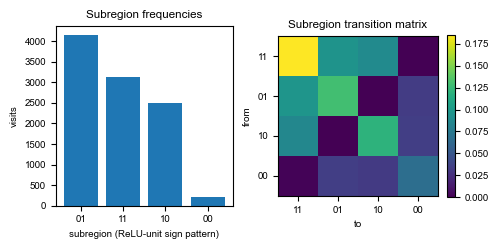

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))

order = np.argsort(-freqs)
axes[0].bar(np.arange(len(freqs)), freqs[order])
axes[0].set_xticks(np.arange(len(freqs)))
axes[0].set_xticklabels([''.join(map(str, regions[i])) for i in order])
axes[0].set_xlabel('subregion (ReLU-unit sign pattern)')
axes[0].set_ylabel('visits')
axes[0].set_title('Subregion frequencies')

im = axes[1].imshow(conn, cmap='viridis')
axes[1].set_xticks(np.arange(len(regions)))
axes[1].set_yticks(np.arange(len(regions)))
axes[1].set_xticklabels([''.join(map(str, r)) for r in regions])
axes[1].set_yticklabels([''.join(map(str, r)) for r in regions])
axes[1].set_xlabel('to')
axes[1].set_ylabel('from')
axes[1].set_title('Subregion transition matrix')
fig.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.savefig(FIG_DIR / "alrnn_subregion_statistics.png", dpi=150)
plt.show()

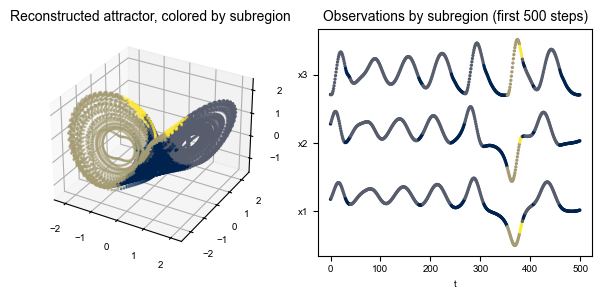

In [90]:
# Color the reconstructed attractor and observation traces by subregion
obs_alrnn = lat_alrnn[:, :ds_lorenz.N]
cmap = plt.get_cmap('cividis')
colors = cmap(codes / max(codes.max(), 1))

fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(121, projection='3d')
ax.scatter(*obs_alrnn.T, c=colors, s=1, alpha=0.5)
ax.set_title('Reconstructed attractor, colored by subregion', fontsize=10)

ax2 = fig.add_subplot(122)
seg = slice(0, 500)
for d in range(ds_lorenz.N):
    ax2.scatter(np.arange(seg.stop), obs_alrnn[seg, d] + 4 * d, c=colors[seg], s=2)
ax2.set_yticks([4 * d for d in range(ds_lorenz.N)])
ax2.set_yticklabels([f'x{d + 1}' for d in range(ds_lorenz.N)])
ax2.set_xlabel('t')
ax2.set_title('Observations by subregion (first 500 steps)', fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / "alrnn_subregion_attractor.png", dpi=150)
plt.show()

## Summary

This notebook walked through the two main use cases of the NeuralRNN PLRNN family.

Key take-aways:

1. **M > N with sparse hard teacher forcing**: the ALRNN / dendPLRNN references reconstruct Lorenz-63 with a latent dim larger than the observation dim (observations = first N latent units, learned `init_state_from_obs` lift), hard forcing (alpha=1) every tau steps, RAdam with exponential lr decay, and best-checkpoint selection by free-run D_stsp — all reproducible here via `TeacherForcingObjective(alpha, forcing_interval, tf_noise)` + `TrainingArguments(optimizer='radam', lr_scheduler='exponential', eval_metric='d_stsp', keep_best=True)`.
2. **Non-autonomous PLRNNs** reconstruct task-conditioned neural activity by feeding task covariates through the unified `inputs` batch key and setting `autonomous=False`.
4. For task-state models, the **analytic** fixed-point backend works when the task input is held constant: the framework computes `h1_eff = h1 + C s*` and runs SCYFI on the equivalent autonomous map.
3. **Unified reconstruction data**: windowed time series (`ReconstructionDataset.from_timeseries`, used for `lorenz63`) and trial-aligned teacher recordings (`ReconstructionDataset(inputs, activity)`) share the same `activity` / `inputs` batch schema consumed by `TeacherForcingObjective`.
4. The Lorenz-63 `lambda_max` must be divided by the sampling interval `dt=0.01` to compare with the continuous-time ground truth (~0.906).
5. **Fixed-point recovery**: all three Lorenz models expose an equivalent shallow-PLRNN form to SCYFI, so their FPs can be overlaid on the 3-D trajectories (first $N$ latent coords).